In [380]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [381]:
df=pd.read_csv('StudentPerformanceFactors.csv')

In [382]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [383]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [384]:
df.shape

(6607, 20)

In [385]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [386]:
df.duplicated().sum()

np.int64(0)

In [387]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [388]:
df[df.Exam_Score>100]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


In [389]:
df=df[df["Exam_Score"] <= 100]

<Axes: >

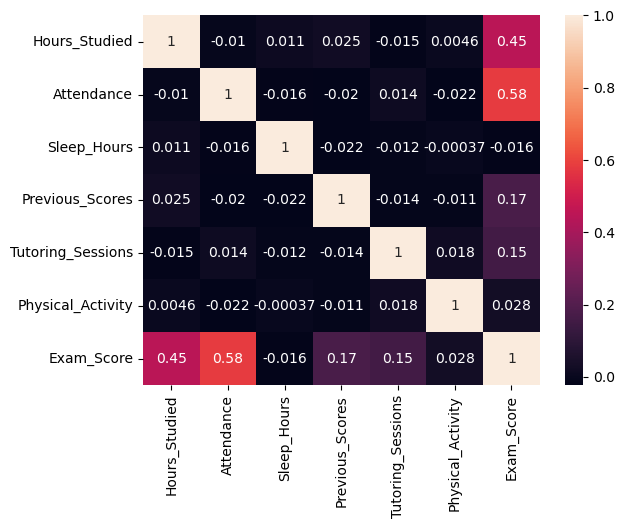

In [390]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [391]:
cat_features=[
              'Parental_Involvement','Access_to_Resources','Extracurricular_Activities','Motivation_Level','Internet_Access','Family_Income','Teacher_Quality','School_Type','Peer_Influence','Learning_Disabilities','Parental_Education_Level','Distance_from_Home','Gender'	
]

In [392]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha =0.05

df['Exam_Score_bin']=pd.qcut(df['Exam_Score'],q=4,labels=False)
chi2_results={}

for col in cat_features:
    contingency=pd.crosstab(df[col],df['Exam_Score_bin'])
    chi2_stat,p_val,_,_=chi2_contingency(contingency)
    decision='Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col]={
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df=pd.DataFrame(chi2_results).T
chi2_df=chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
Access_to_Resources,219.48025,0.0,Reject Null (Keep Feature)
Parental_Involvement,164.154103,0.0,Reject Null (Keep Feature)
Peer_Influence,83.849906,0.0,Reject Null (Keep Feature)
Parental_Education_Level,82.619509,0.0,Reject Null (Keep Feature)
Distance_from_Home,65.539592,0.0,Reject Null (Keep Feature)
Motivation_Level,62.432299,0.0,Reject Null (Keep Feature)
Family_Income,61.499784,0.0,Reject Null (Keep Feature)
Learning_Disabilities,51.718645,0.0,Reject Null (Keep Feature)
Teacher_Quality,40.400063,0.0,Reject Null (Keep Feature)
Extracurricular_Activities,28.813519,0.000002,Reject Null (Keep Feature)


In [393]:
# df["Teacher_Quality"].fillna(df["Teacher_Quality"].mode()[0], inplace=True)
# df["Parental_Education_Level"].fillna(df["Parental_Education_Level"].mode()[0], inplace=True)
# df["Distance_from_Home"].fillna(df["Distance_from_Home"].mode()[0], inplace=True)

In [394]:
df=pd.get_dummies(df,columns=cat_features,drop_first=True)

In [395]:
# df.drop(['School_Type','Physical_Activity','Gender','Sleep_Hours'],inplace=True,axis=1)
df.drop(['Exam_Score_bin'],inplace=True,axis=1)

In [396]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6606 entries, 0 to 6606
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   Hours_Studied                          6606 non-null   int64
 1   Attendance                             6606 non-null   int64
 2   Sleep_Hours                            6606 non-null   int64
 3   Previous_Scores                        6606 non-null   int64
 4   Tutoring_Sessions                      6606 non-null   int64
 5   Physical_Activity                      6606 non-null   int64
 6   Exam_Score                             6606 non-null   int64
 7   Parental_Involvement_Low               6606 non-null   bool 
 8   Parental_Involvement_Medium            6606 non-null   bool 
 9   Access_to_Resources_Low                6606 non-null   bool 
 10  Access_to_Resources_Medium             6606 non-null   bool 
 11  Extracurricular_Activities_Yes     

In [397]:
# from sklearn.preprocessing import LabelEncoder
# le= LabelEncoder()

In [398]:
df.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,7,73,0,3,67,True,False,False,...,True,True,False,True,False,True,False,False,True,True
1,19,64,8,59,2,4,61,True,False,False,...,True,True,False,False,False,False,False,True,False,False
2,24,98,7,91,2,4,74,False,True,False,...,True,True,True,False,False,False,True,False,True,True
3,29,89,8,98,1,4,71,True,False,False,...,True,True,False,False,False,True,False,True,False,True
4,19,92,6,65,3,4,70,False,True,False,...,False,True,True,False,False,False,False,False,True,False


In [399]:
# df['Parental_Involvement'].value_counts()

In [400]:
# df['Access_to_Resources'].value_counts()

In [401]:
# df['Parental_Involvement']=le.fit_transform(df["Parental_Involvement"])
# df['Access_to_Resources']=le.fit_transform(df["Access_to_Resources"])
# df['Motivation_Level']=le.fit_transform(df["Motivation_Level"])
# df['Extracurricular_Activities']=le.fit_transform(df["Extracurricular_Activities"])
# df['Internet_Access']=le.fit_transform(df["Internet_Access"])
# df['Learning_Disabilities']=le.fit_transform(df["Learning_Disabilities"])
# df['Family_Income']=le.fit_transform(df["Family_Income"])
# df['Peer_Influence']=le.fit_transform(df["Peer_Influence"])
# df['Teacher_Quality']=le.fit_transform(df["Teacher_Quality"])
# df['Parental_Education_Level']=le.fit_transform(df["Parental_Education_Level"])
# df['Distance_from_Home']=le.fit_transform(df["Distance_from_Home"])

In [402]:
df.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,7,73,0,3,67,True,False,False,...,True,True,False,True,False,True,False,False,True,True
1,19,64,8,59,2,4,61,True,False,False,...,True,True,False,False,False,False,False,True,False,False
2,24,98,7,91,2,4,74,False,True,False,...,True,True,True,False,False,False,True,False,True,True
3,29,89,8,98,1,4,71,True,False,False,...,True,True,False,False,False,True,False,True,False,True
4,19,92,6,65,3,4,70,False,True,False,...,False,True,True,False,False,False,False,False,True,False


In [403]:
df.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,7,73,0,3,67,True,False,False,...,True,True,False,True,False,True,False,False,True,True
1,19,64,8,59,2,4,61,True,False,False,...,True,True,False,False,False,False,False,True,False,False
2,24,98,7,91,2,4,74,False,True,False,...,True,True,True,False,False,False,True,False,True,True
3,29,89,8,98,1,4,71,True,False,False,...,True,True,False,False,False,True,False,True,False,True
4,19,92,6,65,3,4,70,False,True,False,...,False,True,True,False,False,False,False,False,True,False


In [404]:
from sklearn.model_selection import train_test_split

In [405]:
X = df.drop('Exam_Score',axis=1)
y = df['Exam_Score']

In [406]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [407]:
from sklearn.preprocessing import StandardScaler
# cols=['Hours_Studied','Attendance','Previous_Scores']
# scaler=StandardScaler()

# df[cols]=scaler.fit_transform(df[cols])
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [408]:
from sklearn.linear_model import LinearRegression

In [409]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [410]:
y_pred = model.predict(X_test)

In [411]:
y_pred

array([66.01402805, 65.43553764, 67.55862055, ..., 66.22132309,
       69.37571691, 72.02326671], shape=(1322,))

In [412]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)
print(r2)
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1-((1- r2) * (n-1) / (n - p - 1))
print(adjusted_r2)

0.8245140267017717
0.820852418294467


In [413]:
import pickle

pickle.dump(model, open("student_model.pkl", "wb"))

In [414]:
X.columns

Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Parental_Involvement_Low',
       'Parental_Involvement_Medium', 'Access_to_Resources_Low',
       'Access_to_Resources_Medium', 'Extracurricular_Activities_Yes',
       'Motivation_Level_Low', 'Motivation_Level_Medium',
       'Internet_Access_Yes', 'Family_Income_Low', 'Family_Income_Medium',
       'Teacher_Quality_Low', 'Teacher_Quality_Medium', 'School_Type_Public',
       'Peer_Influence_Neutral', 'Peer_Influence_Positive',
       'Learning_Disabilities_Yes', 'Parental_Education_Level_High School',
       'Parental_Education_Level_Postgraduate', 'Distance_from_Home_Moderate',
       'Distance_from_Home_Near', 'Gender_Male'],
      dtype='object')

In [415]:
import joblib

joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'columns.pkl')

['columns.pkl']

In [416]:
print(df['Hours_Studied'].min())
print(df['Hours_Studied'].max())

1
44
